In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.regularizers import l2
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\forecasting_feature_set.csv')

df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

drop_cols = [
    'net_load_lag_1h', 'net_load_lag_24h',
    'demand_lag_1h', 'demand_lag_24h',
    'wind_gen_lag_24h'
]

df_lstm = df.drop(columns=drop_cols, errors='ignore')

split_index = int(len(df_lstm) * 0.8)

train_df = df_lstm.iloc[:split_index]
test_df  = df_lstm.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler_X = StandardScaler()
scaler_y = StandardScaler()

X_train_scaled = scaler_X.fit_transform(X_train)
X_test_scaled  = scaler_X.transform(X_test)

y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

def create_sequences(X, y, seq_length):
    Xs, ys = [], []
    for i in range(seq_length, len(X)):
        Xs.append(X[i-seq_length:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

SEQ_LENGTH = 96  

X_train_seq, y_train_seq = create_sequences(X_train_scaled, y_train_scaled, SEQ_LENGTH)
X_test_seq, y_test_seq   = create_sequences(X_test_scaled, y_test_scaled, SEQ_LENGTH)

model = Sequential([
    LSTM(64, return_sequences=True, input_shape=(SEQ_LENGTH, X_train_seq.shape[2])),
    LSTM(32),
    Dense(16, activation='relu', kernel_regularizer=l2(1e-4)),
    Dense(1)
])

model.compile(
    optimizer='adam',
    loss='mae'
)

model.summary()

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=7,
    restore_best_weights=True
)

lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=5,
    min_lr=1e-5
)

history = model.fit(
    X_train_seq, y_train_seq,
    epochs=50,
    batch_size=64,
    validation_split=0.1,
    callbacks=[early_stop, lr_scheduler],
    verbose=1
)

y_pred_scaled = model.predict(X_test_seq)

y_pred = scaler_y.inverse_transform(y_pred_scaled)
y_test_actual = scaler_y.inverse_transform(y_test_seq)

y_pred = y_pred.flatten()
y_test_actual = y_test_actual.flatten()

c:\Users\Hp\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 96, 64)         │        24,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,793 (147.63 KB)

 Trainable params: 37,793 (147.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 81s 66ms/step - loss: 0.0709 - val_loss: 0.0681 - learning_rate: 0.0010
Epoch 2/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 81s 69ms/step - loss: 0.0470 - val_loss: 0.0513 - learning_rate: 0.0010
Epoch 3/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 83s 70ms/step - loss: 0.0429 - val_loss: 0.0502 - learning_rate: 0.0010
Epoch 4/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 139s 67ms/step - loss: 0.0416 - val_loss: 0.0507 - learning_rate: 0.0010
Epoch 5/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.0397 - val_loss: 0.0653 - learning_rate: 0.0010
Epoch 6/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.0386 - val_loss: 0.0480 - learning_rate: 0.0010
Epoch 7/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 82s 69ms/step - loss: 0.0377 - val_loss: 0.0618 - learning_rate: 0.0010
Epoch 8/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.0368 - val_loss: 0.0469 - learning_rate: 0.0010
Epoch 9/50
1183/1183 ━━━━━━━━━━━━━━━━━━━━ 84s 71ms/step - loss: 0.0361 - val_loss: 0.04

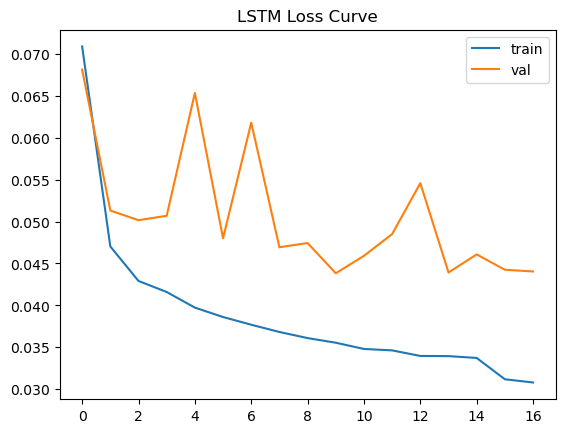

In [10]:
plt.plot(history.history['loss'], label='train')
plt.plot(history.history['val_loss'], label='val')
plt.legend()
plt.title("LSTM Loss Curve")
plt.show()

In [3]:
rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
mae  = mean_absolute_error(y_test_actual, y_pred)
r2   = r2_score(y_test_actual, y_pred)
epsilon = 1e-6
mape = np.mean(np.abs((y_test_actual - y_pred) / (y_test_actual + epsilon))) * 100

print("LSTM PERFORMANCE METRICS")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test_actual - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")

LSTM PERFORMANCE METRICS
RMSE : 324.0547
MAE  : 219.8439
R²   : 0.9973
MAPE : 1.26%

Error Summary:
Mean Error      : 26.4430
Std Error       : 322.9741
Max Error       : 3521.7428


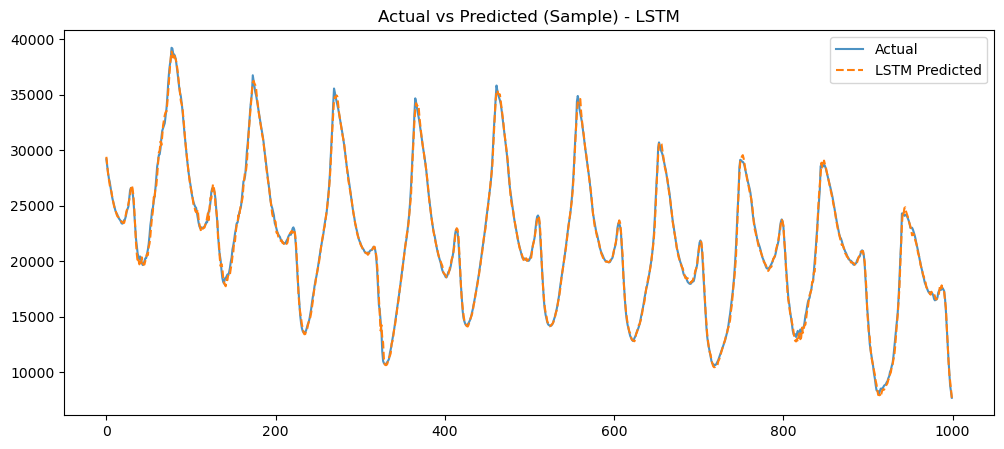

In [8]:
start = 10000
end = 11000

plt.figure(figsize=(12, 5))
plt.plot(y_test_actual[start:end], label="Actual", alpha=0.8)
plt.plot(y_pred[start:end], label="LSTM Predicted", linestyle='--')
plt.title("Actual vs Predicted (Sample) - LSTM")
plt.legend()
plt.show()

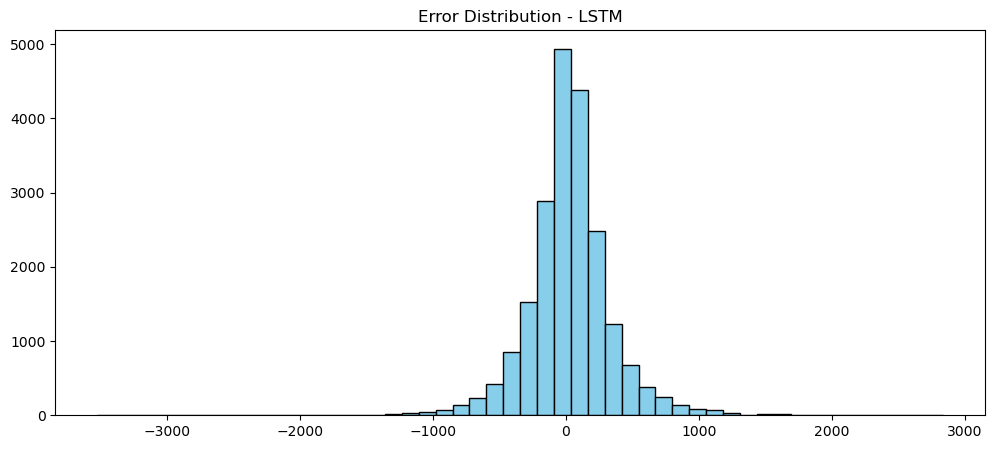

In [5]:
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=50, color = 'skyblue', edgecolor = 'black')
plt.title("Error Distribution - LSTM")
plt.show()

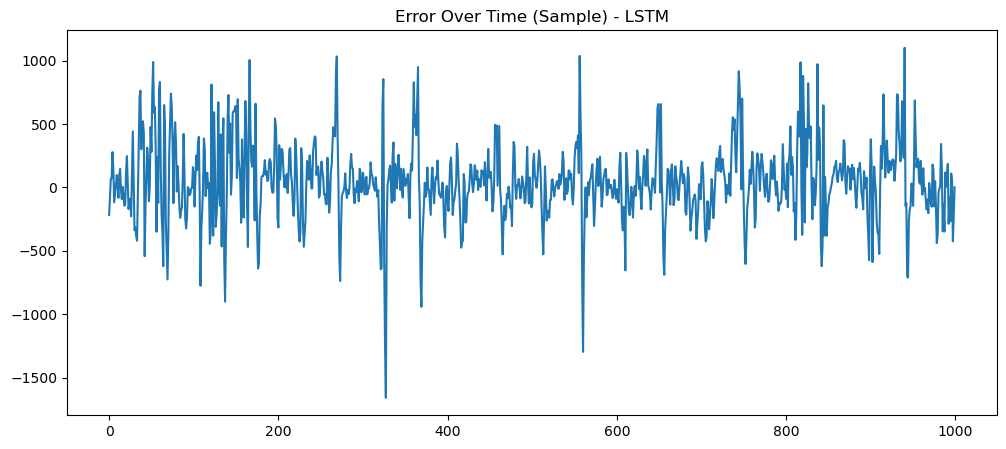

In [9]:
plt.figure(figsize=(12, 5))
plt.plot(errors[start:end])
plt.title("Error Over Time (Sample) - LSTM")
plt.show()

In [11]:
import pickle

model.save('lstm_model.keras')

scalers = {
    'scaler_X': scaler_X,
    'scaler_y': scaler_y,
    'seq_length': SEQ_LENGTH,
    'feature_cols': list(X_train.columns) 
}

with open('scalers.pkl', 'wb') as f:
    pickle.dump(scalers, f)

print("Model and scalers saved successfully")

Model and scalers saved successfully


In [12]:
errors = y_test_actual - y_pred
abs_errors = np.abs(errors)

mean_error = np.mean(abs_errors)
std_error  = np.std(abs_errors)

print(f"Mean Absolute Error : {mean_error:.4f}")
print(f"Std of Errors       : {std_error:.4f}")
print(f"Max Error           : {np.max(abs_errors):.4f}")

threshold_watch    = mean_error + 1.5 * std_error
threshold_warning  = mean_error + 2.0 * std_error
threshold_critical = mean_error + 3.0 * std_error

print(f"\nThreshold WATCH    : {threshold_watch:.4f}")
print(f"Threshold WARNING  : {threshold_warning:.4f}")
print(f"Threshold CRITICAL : {threshold_critical:.4f}")

def assign_alert(error):
    abs_err = abs(error)
    if abs_err >= threshold_critical:
        return 'CRITICAL'
    elif abs_err >= threshold_warning:
        return 'WARNING'
    elif abs_err >= threshold_watch:
        return 'WATCH'
    else:
        return 'NORMAL'

alert_levels = [assign_alert(e) for e in errors]

results_df = pd.DataFrame({
    'actual'     : y_test_actual,
    'predicted'  : y_pred,
    'error'      : errors,
    'abs_error'  : abs_errors,
    'alert_level': alert_levels
})

PERSISTENCE_WINDOW = 3

results_df['alert_numeric'] = (results_df['alert_level'] != 'NORMAL').astype(int)
results_df['sustained_alert'] = (
    results_df['alert_numeric']
    .rolling(PERSISTENCE_WINDOW)
    .sum() >= PERSISTENCE_WINDOW
).astype(int)

print(f"\nAlert Distribution:")
print(results_df['alert_level'].value_counts())
print(f"\nSustained Alert Events: {results_df['sustained_alert'].sum()}")

Mean Absolute Error : 219.8439
Std of Errors       : 238.0759
Max Error           : 3521.7428

Threshold WATCH    : 576.9578
Threshold WARNING  : 695.9957
Threshold CRITICAL : 934.0716

Alert Distribution:
alert_level
NORMAL      19440
WATCH         566
WARNING       557
CRITICAL      384
Name: count, dtype: int64

Sustained Alert Events: 227


In [13]:
early_warning_config = {
    'threshold_watch'    : threshold_watch,
    'threshold_warning'  : threshold_warning,
    'threshold_critical' : threshold_critical,
    'persistence_window' : PERSISTENCE_WINDOW,
    'mean_error'         : mean_error,
    'std_error'          : std_error
}

with open('early_warning_config.pkl', 'wb') as f:
    pickle.dump(early_warning_config, f)

# Save results for frontend historical view
results_df.to_csv('lstm_predictions_with_alerts.csv', index=False)

print("Early warning config and results saved")

Early warning config and results saved


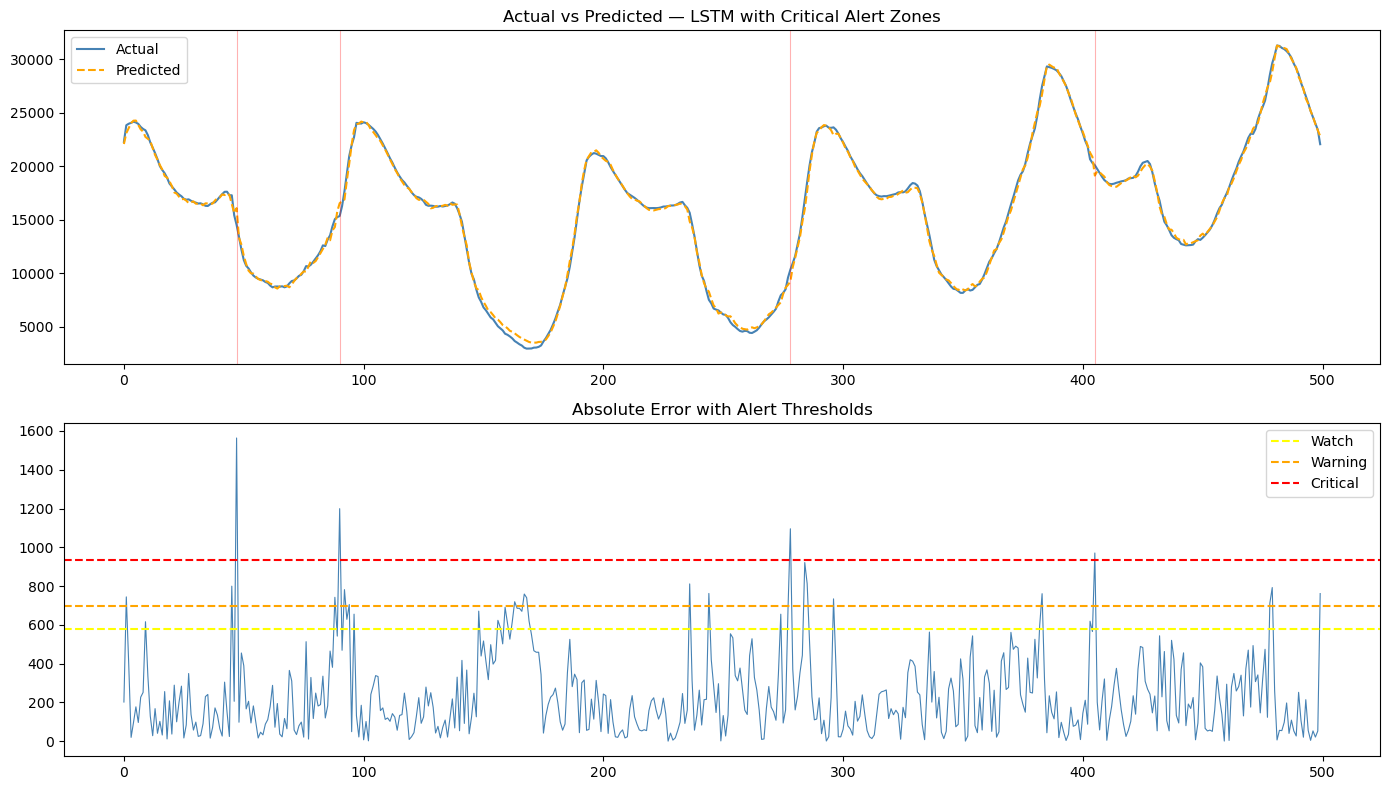

In [14]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

axes[0].plot(y_test_actual[:500], label='Actual', color='steelblue')
axes[0].plot(y_pred[:500], label='Predicted', color='orange', linestyle='--')

critical_idx = results_df[results_df['alert_level'] == 'CRITICAL'].index[:500]
for idx in critical_idx:
    if idx < 500:
        axes[0].axvline(x=idx, color='red', alpha=0.3, linewidth=0.8)

axes[0].set_title('Actual vs Predicted — LSTM with Critical Alert Zones')
axes[0].legend()

axes[1].plot(abs_errors[:500], color='steelblue', linewidth=0.8)
axes[1].axhline(y=threshold_watch,    color='yellow', linestyle='--', label='Watch')
axes[1].axhline(y=threshold_warning,  color='orange', linestyle='--', label='Warning')
axes[1].axhline(y=threshold_critical, color='red',    linestyle='--', label='Critical')
axes[1].set_title('Absolute Error with Alert Thresholds')
axes[1].legend()

plt.tight_layout()
plt.show()